# Imports & Data Loading

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [116]:
df = pd.read_csv("data/airlines_flights_data.csv")
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [117]:
df.tail()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


# Quality Evaluation
### Thorough assessment of dataset integrity, covering missing data analysis, duplicate detection, and data type refinement for optimal performance.

In [119]:
df.shape

(300153, 12)

In [120]:
df.columns

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [121]:
df.dtypes

index                 int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [123]:
df.isnull().sum()

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [124]:
df.duplicated().sum()

0

In [125]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


# Exploratory Data Analysis

### Histograms

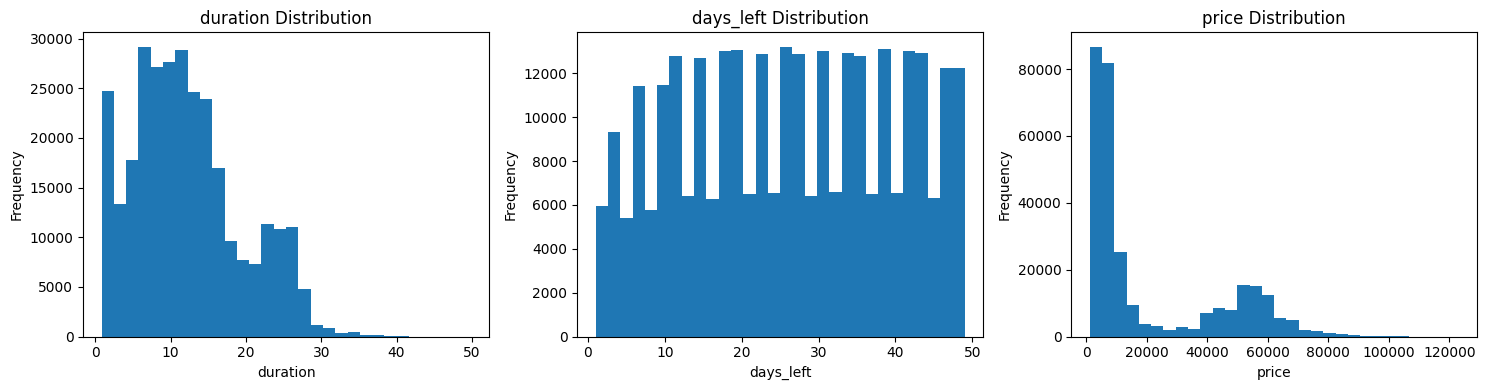

In [128]:
# Numerical Columns Histograms

numerical_cols = ['duration', 'days_left', 'price']
plt.figure(figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)  # 1 row, 3 columns
    plt.hist(df[col], bins=30)
    plt.title(col + " Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Boxplots

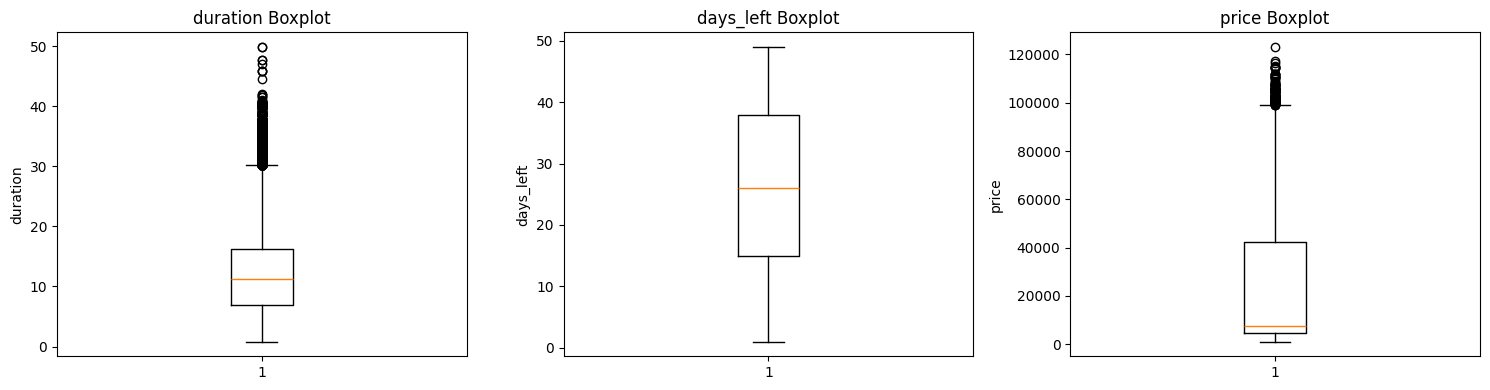

In [130]:
# Numerical Columns Boxplots

plt.figure(figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    plt.boxplot(df[col])
    plt.title(col + " Boxplot")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Skewness and Kurtosis

In [132]:
for col in numerical_cols:
    print("Column:", col)
    
    skew_value = df[col].skew()
    print("Skewness:", round(skew_value, 2))
    
    kurt_value = df[col].kurtosis()
    print("Kurtosis:", round(kurt_value, 2))
    
    print("------------------------")

Column: duration
Skewness: 0.6
Kurtosis: -0.27
------------------------
Column: days_left
Skewness: -0.04
Kurtosis: -1.16
------------------------
Column: price
Skewness: 1.06
Kurtosis: -0.4
------------------------


In [133]:
# Categorical Columns 

cat_columns = [
    'airline',
    'class',
    'stops',
    'source_city',
    'destination_city',
    'departure_time',
    'arrival_time'
]

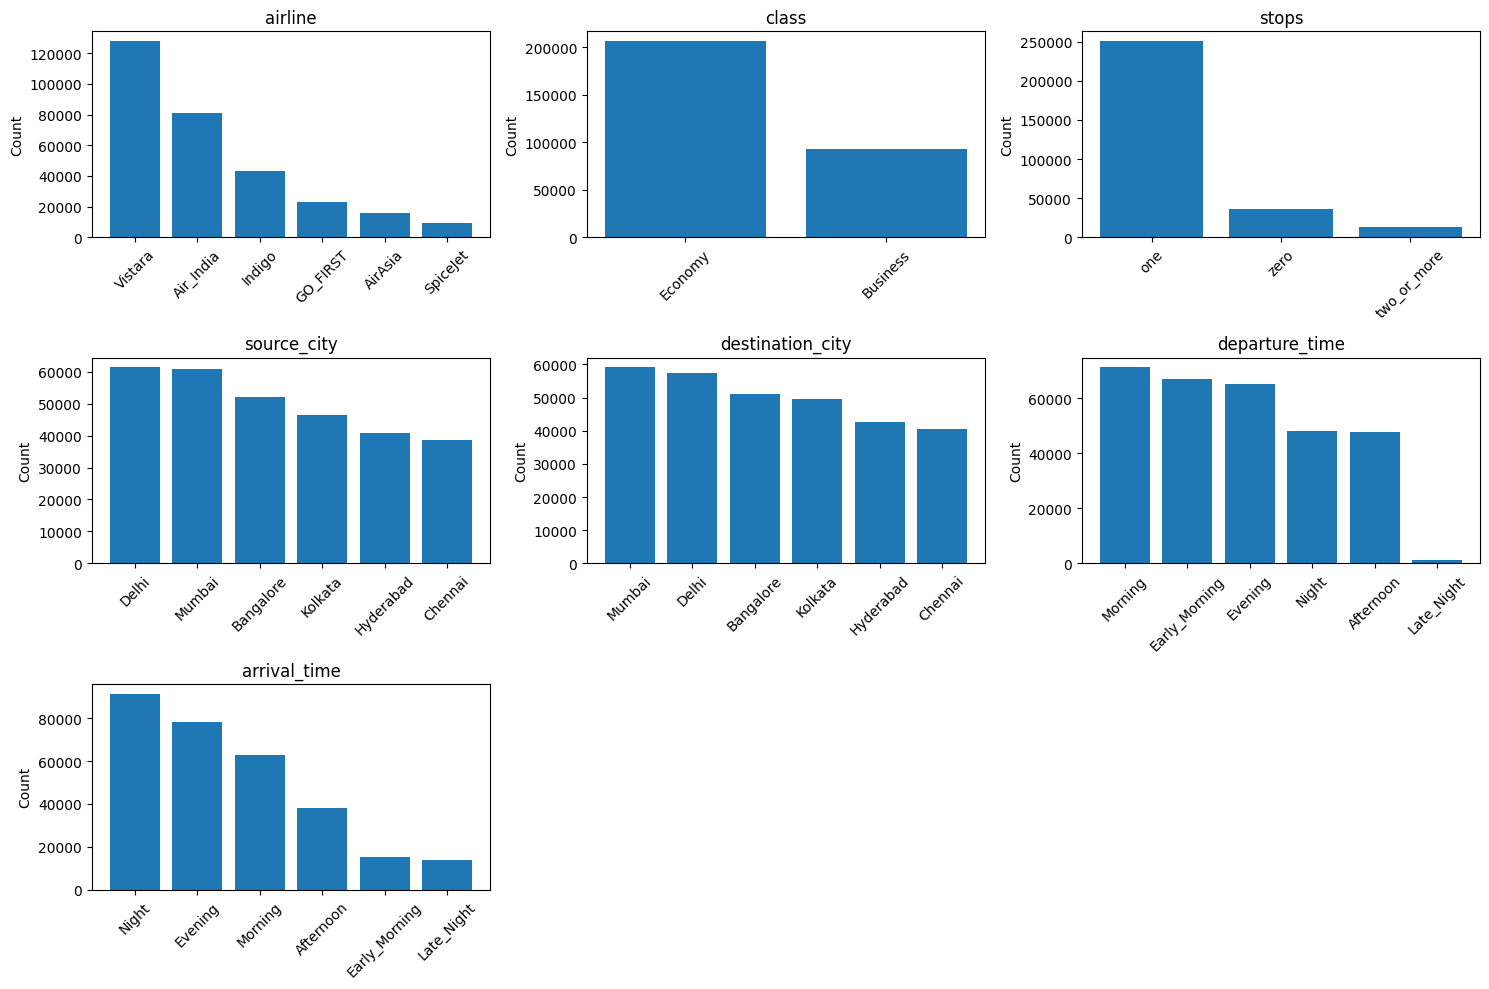

In [134]:
# Bar Charts for Categorical Columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_columns):
    
    plt.subplot(3, 3, i+1)
    
    counts = df[col].value_counts()
    
    plt.bar(counts.index.astype(str), counts.values)
    
    plt.title(col)
    plt.xticks(rotation=45)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

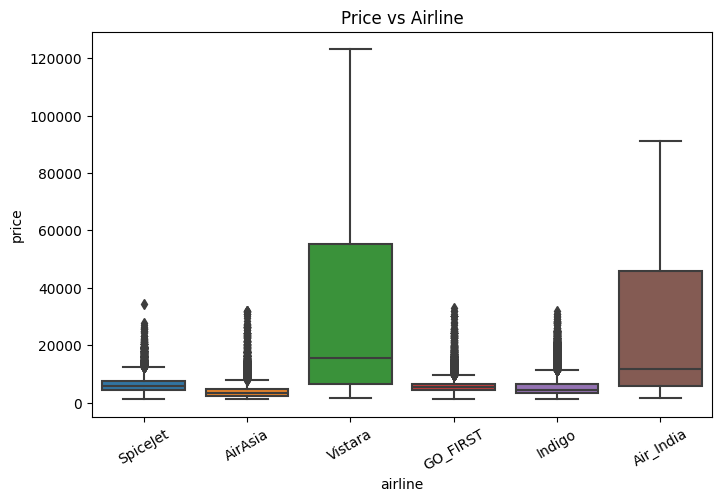

In [135]:
# Price vs Airline

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='airline', y='price')

plt.title("Price vs Airline")
plt.xticks(rotation=30)
plt.show()

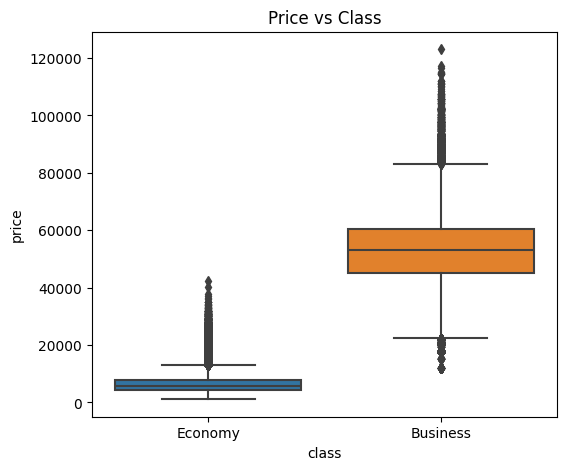

In [136]:
# Price vs Class

plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='class', y='price')

plt.title("Price vs Class")
plt.show()

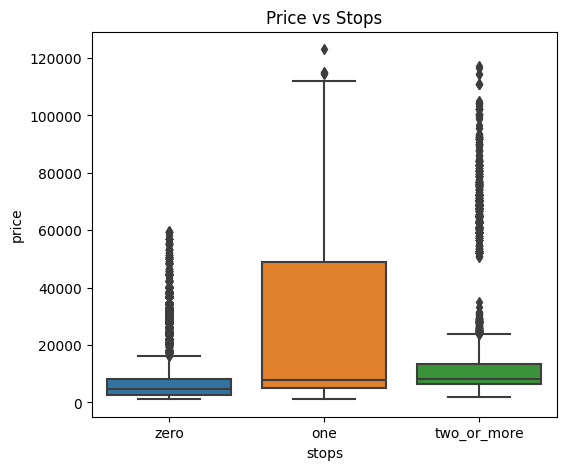

In [137]:
# Price vs Stops

plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='stops', y='price')

plt.title("Price vs Stops")
plt.show()

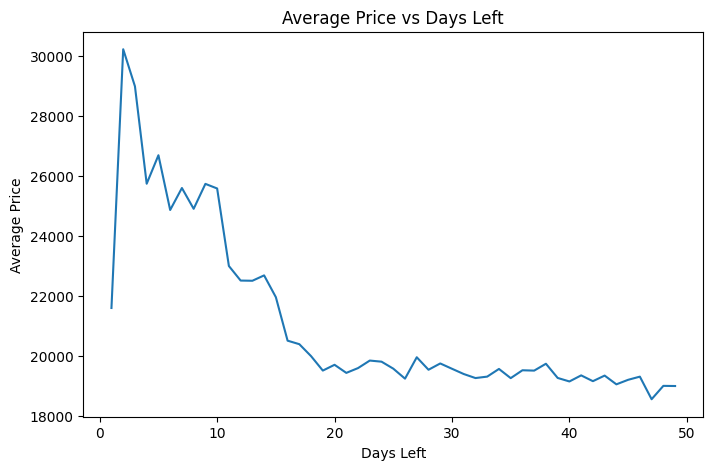

In [138]:
# Average Price vs Days Left

avg_price_days = df.groupby('days_left')['price'].mean()

plt.figure(figsize=(8,5))

plt.plot(avg_price_days.index, avg_price_days.values)

plt.title("Average Price vs Days Left")
plt.xlabel("Days Left")
plt.ylabel("Average Price")
plt.show()

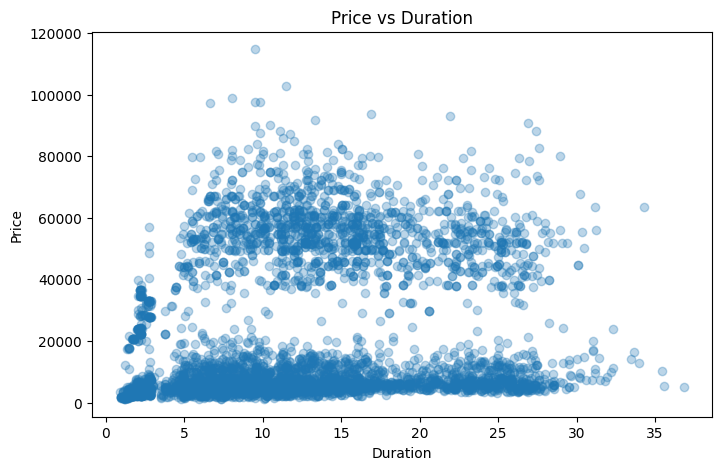

In [139]:
# Price vs Duration

sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(sample['duration'], sample['price'], alpha=0.3)

plt.title("Price vs Duration")
plt.xlabel("Duration")
plt.ylabel("Price")
plt.show()

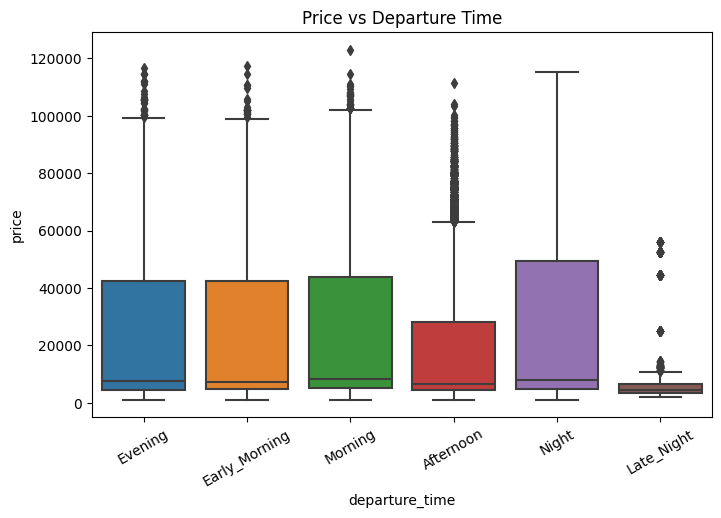

In [140]:
# Price vs Departure Time

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='departure_time', y='price')

plt.title("Price vs Departure Time")
plt.xticks(rotation=30)
plt.show()

### Correlation Heatmap

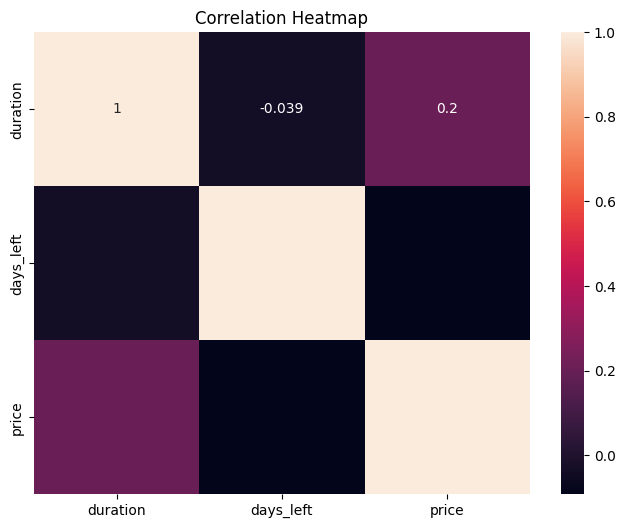

In [142]:
# Numerical Columns

corr = df[numerical_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

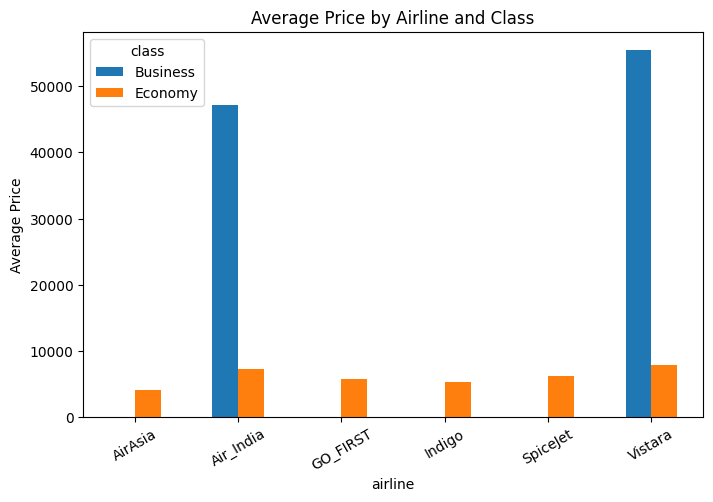

In [143]:
# Average Price by Airline and Class

pivot_table = df.pivot_table(
    values='price',
    index='airline',
    columns='class',
    aggfunc='mean'
)

pivot_table.plot(kind='bar', figsize=(8,5))

plt.title("Average Price by Airline and Class")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.show()

In [144]:
# Create Route Column

df['route'] = df['source_city'].astype(str) + " -> " + df['destination_city'].astype(str)

df[['source_city', 'destination_city', 'route']].head()

,source_city,destination_city,route
0,Delhi,Mumbai,Delhi -> Mumbai
1,Delhi,Mumbai,Delhi -> Mumbai
2,Delhi,Mumbai,Delhi -> Mumbai
3,Delhi,Mumbai,Delhi -> Mumbai
4,Delhi,Mumbai,Delhi -> Mumbai


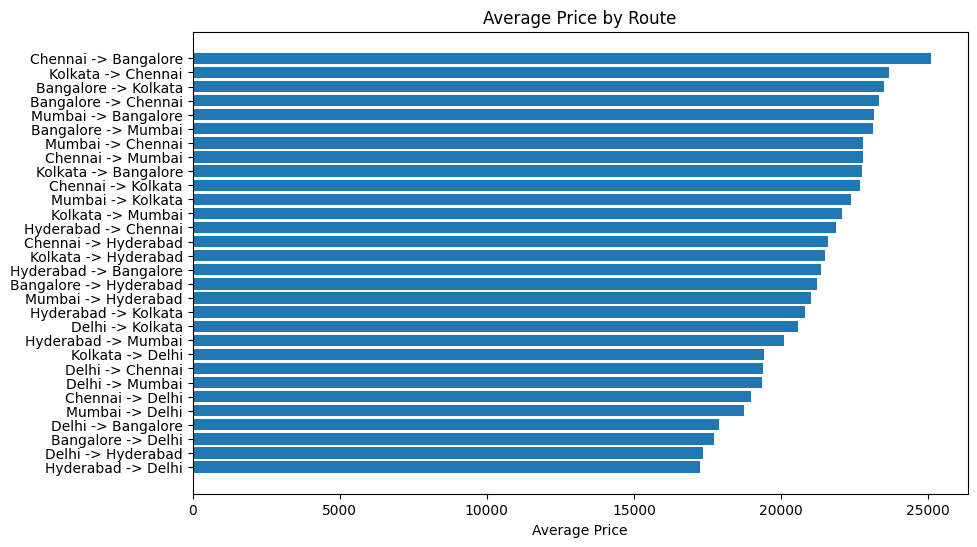

In [145]:
# Average Price by Route

route_price = df.groupby('route')['price'].mean()

route_price = route_price.sort_values(ascending=False)

plt.figure(figsize=(10,6))

plt.barh(route_price.index, route_price.values)

plt.xlabel("Average Price")
plt.title("Average Price by Route")
plt.gca().invert_yaxis()   # Highest price on top
plt.show()

### Airlines and Their Frequencies

In [147]:
# Airline Frequencies

airline_counts = df['airline'].value_counts()

total_flights = len(df)

print("Airlines and number of flights:\n")

for airline in airline_counts.index:
    count = airline_counts[airline]
    percentage = (count / total_flights) * 100
    print(airline, ":", count, "flights (", round(percentage, 1), "% )")

Airlines and number of flights:

Vistara : 127859 flights ( 42.6 % )
Air_India : 80892 flights ( 27.0 % )
Indigo : 43120 flights ( 14.4 % )
GO_FIRST : 23173 flights ( 7.7 % )
AirAsia : 16098 flights ( 5.4 % )
SpiceJet : 9011 flights ( 3.0 % )


In [148]:
# Price by Airline

airline_price_stats = df.groupby('airline')['price'].agg(['mean', 'median', 'std'])

print("Price statistics by airline:\n")
print(airline_price_stats.sort_values('mean', ascending=False))

print("\nConclusion:")
print("Yes, prices are different for each airline.")
print("Vistara and Air India are usually more expensive.")

Price statistics by airline:

                   mean   median           std
airline                                       
Vistara    30396.536302  15543.0  25637.159445
Air_India  23507.019112  11520.0  20905.116909
SpiceJet    6179.278881   5654.0   2999.630406
GO_FIRST    5652.007595   5336.0   2513.865560
Indigo      5324.216303   4453.0   3268.894831
AirAsia     4091.072742   3276.0   2824.055172

Conclusion:
Yes, prices are different for each airline.
Vistara and Air India are usually more expensive.


In [149]:
# Price by Time of Day

for column in ['departure_time', 'arrival_time']:
    print("\nAverage price by", column)
    
    avg_price = df.groupby(column)['price'].mean().sort_values(ascending=False)
    
    for time in avg_price.index:
        print(time, ":", round(avg_price[time]))


Average price by departure_time
Night : 23062
Morning : 21631
Evening : 21232
Early_Morning : 20371
Afternoon : 18179
Late_Night : 9295

Average price by arrival_time
Evening : 23044
Morning : 22231
Night : 21587
Afternoon : 18495
Early_Morning : 14993
Late_Night : 11285


In [150]:
# Price by Route

route_price = df.groupby(
    ['source_city', 'destination_city']
)['price'].mean()

route_price_sorted = route_price.sort_values(ascending=False)

print("Top 10 most expensive routes:\n")
print(route_price_sorted.head(10))

Top 10 most expensive routes:

source_city  destination_city
Chennai      Bangalore           25081.850454
Kolkata      Chennai             23660.361040
Bangalore    Kolkata             23500.061229
             Chennai             23321.850078
Mumbai       Bangalore           23147.873807
Bangalore    Mumbai              23128.618672
Mumbai       Chennai             22781.899112
Chennai      Mumbai              22765.849647
Kolkata      Bangalore           22744.808428
Chennai      Kolkata             22669.932407
Name: price, dtype: float64


In [151]:
# Last-Minute vs Regular Booking

last_minute = df[df['days_left'] <= 2]
regular = df[df['days_left'] > 2]

last_min_avg = last_minute['price'].mean()
regular_avg = regular['price'].mean()

print("Last-minute bookings (<= 2 days):", round(last_min_avg))
print("Regular bookings (> 2 days):", round(regular_avg))

price_ratio = last_min_avg / regular_avg
print("Last-minute is", round(price_ratio, 2), "times more expensive")

Last-minute bookings (<= 2 days): 27421
Regular bookings (> 2 days): 20757
Last-minute is 1.32 times more expensive


In [152]:
# Class Comparison

class_price = df.groupby('class')['price'].agg(['mean', 'median', 'min', 'max'])

print("Price comparison by class:\n")
print(class_price)

business_avg = class_price.loc['Business', 'mean']
economy_avg = class_price.loc['Economy', 'mean']

print("\nBusiness class is",
      round(business_avg / economy_avg, 1),
      "times more expensive than Economy.")

Price comparison by class:

                  mean   median    min     max
class                                         
Business  52540.081124  53164.0  12000  123071
Economy    6572.342383   5772.0   1105   42349

Business class is 8.0 times more expensive than Economy.


In [153]:
# Specific Route


filtered_data = df[
    (df['airline'] == 'Vistara') &
    (df['source_city'] == 'Delhi') &
    (df['destination_city'] == 'Hyderabad') &
    (df['class'] == 'Business')
]

print("Number of matching flights:", len(filtered_data))
print("Average price:", round(filtered_data['price'].mean()))
print("Median price:", round(filtered_data['price'].median()))
print("Min price:", filtered_data['price'].min())
print("Max price:", filtered_data['price'].max())

Number of matching flights: 1660
Average price: 47940
Median price: 51697
Min price: 24056
Max price: 114507


# Feature Engineering

In [155]:
# Creating a copy for the dataset
df_ml = df.copy()
print("Dataset Copied")

Dataset Copied


### Price per Hour Feature

In [157]:
duration_fixed = df_ml['duration'].replace(0, np.nan)

df_ml['price_per_hour'] = df_ml['price'] / duration_fixed

# Replace NaN values with 0
df_ml['price_per_hour'] = df_ml['price_per_hour'].fillna(0)

print("Average price per hour:")
print(df_ml['price_per_hour'].mean())

Average price per hour:
2175.4627599985247


### Booking Urgency Feature

In [159]:
def classify_urgency(days):

    if days <= 2:
        return "Last Minute"
    
    elif days <= 7:
        return "Short Notice"
    
    elif days <= 21:
        return "Regular"
    
    else:
        return "Advance"

In [160]:
df_ml['booking_urgency'] = df_ml['days_left'].apply(classify_urgency)

df_ml['booking_urgency'] = df_ml['booking_urgency'].astype('category')

print("Booking urgency distribution:")
print(df_ml['booking_urgency'].value_counts())

Booking urgency distribution:
booking_urgency
Advance         180084
Regular          87956
Short Notice     26160
Last Minute       5953
Name: count, dtype: int64


### Direct Flight Feature

In [162]:
df_ml['is_direct'] = df_ml['stops'] == 'zero'

df_ml['is_direct'] = df_ml['is_direct'].astype(int)

direct_percentage = df_ml['is_direct'].mean() * 100

print("Percentage of direct flights:")
print(direct_percentage)

Percentage of direct flights:
11.995215773288956


### Converting Stops to Numeric

In [164]:
stops_map = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

df_ml['stops_numeric'] = df_ml['stops'].map(stops_map)

df_ml['stops_numeric'] = df_ml['stops_numeric'].astype(int)

print("Unique stop values:")
print(df_ml['stops_numeric'].unique())

Unique stop values:
[0 1 2]


In [165]:
df_ml.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route,price_per_hour,booking_urgency,is_direct,stops_numeric
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi -> Mumbai,2743.317972,Last Minute,1,0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi -> Mumbai,2554.935622,Last Minute,1,0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi -> Mumbai,2744.700461,Last Minute,1,0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi -> Mumbai,2646.666667,Last Minute,1,0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi -> Mumbai,2555.793991,Last Minute,1,0


### Detecting Outliers in Price

In [167]:
Q1 = df_ml['price'].quantile(0.25)
Q3 = df_ml['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Price lower limit:", lower)
print("Price upper limit:", upper)

Price lower limit: -51824.0
Price upper limit: 99128.0


### Cap Price Outliers

In [169]:
df_ml['price'] = df_ml['price'].clip(lower=lower, upper=upper)

print("Price outliers capped")

Price outliers capped


### Detecting Outliers in Duration

In [171]:
Q1 = df_ml['duration'].quantile(0.25)
Q3 = df_ml['duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Duration lower limit:", lower)
print("Duration upper limit:", upper)

Duration lower limit: -7.1800000000000015
Duration upper limit: 30.180000000000003


### Cap Duration Outliers

In [173]:
df_ml['duration'] = df_ml['duration'].clip(lower=lower, upper=upper)

print("Duration outliers capped")

Duration outliers capped


### Recalculate Price per Hour

In [175]:
duration_fixed = df_ml['duration'].replace(0, np.nan)

df_ml['price_per_hour'] = df_ml['price'] / duration_fixed

df_ml['price_per_hour'] = df_ml['price_per_hour'].fillna(0)

print("Price per hour recalculated")

Price per hour recalculated


In [176]:
print("Dataset shape after outlier treatment:")
print(df_ml.shape)

Dataset shape after outlier treatment:
(300153, 17)


# Data Preprocessing

In [224]:
target = "price"

categorical_features = ['airline','source_city','destination_city','departure_time','arrival_time']

binary_features = ['class']

numeric_features = ['duration','days_left','stops_numeric','is_direct']

print("Categorical:", categorical_features)
print("Binary:", binary_features)
print("Numeric:", numeric_features)

Categorical: ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
Binary: ['class']
Numeric: ['duration', 'days_left', 'stops_numeric', 'is_direct']


In [226]:
from sklearn.model_selection import train_test_split

x = df_ml[categorical_features + binary_features + numeric_features]
y = df_ml[target]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42
)

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (240122, 10)
Test Shape: (60031, 10)


In [228]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Binary Encoding
x_train['class'] = (x_train['class'] == 'Business').astype(int)
x_test['class'] = (x_test['class'] == 'Business').astype(int)

In [230]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'),categorical_features)
    ]
)

In [232]:
# Data Transforming

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Processed train shape:", x_train_processed.shape)
print("Processed test shape:", x_test_processed.shape)

Processed train shape: (240122, 29)
Processed test shape: (60031, 29)
